# Company Bankruptcy Prediction

**Author:** Yaqiao Zhang  
**Project type:** Team course project  
**Objective:** Compare machine learning models for identifying companies at risk of bankruptcy using highly imbalanced financial data.

This notebook presents a cleaned portfolio version of the original analysis. The dataset contains 6,819 companies and 95 financial indicators, with bankrupt firms representing only 3.2% of all observations.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)

RANDOM_STATE = 0

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [ ]:
df = pd.read_csv('company_bankruptcy_prediction.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


From the proportion of bankruptcy (96.8% of no bankrupt, 3.2% of bankrupt), we can indicate that this is an imbalanced classification.

In [4]:
df.isnull().sum()
df['Bankrupt?'].value_counts()
df['Bankrupt?'].value_counts(normalize=True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

In [5]:
#Data preprocessing (splitting and scaling)
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train shape: (4773, 95)
X_test shape: (2046, 95)
X_train_scaled shape: (4773, 95)
X_test_scaled shape: (2046, 95)


In [6]:
#Baseline logistic regression model
#Initialize logistic regression model with class_weight="balanced" to handle bankruptcy is rare
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (bankrupt)

In [7]:
# Confusion matrix: how many bankrupt companies were correctly identified?
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report: precision, recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC score: overall classifier discrimination ability
print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_proba))
print("PR AUC Score:", average_precision_score(y_test, y_proba))

Confusion Matrix:
[[1733  247]
 [  18   48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1980
           1       0.16      0.73      0.27        66

    accuracy                           0.87      2046
   macro avg       0.58      0.80      0.60      2046
weighted avg       0.96      0.87      0.91      2046


ROC AUC Score:
0.8814164370982553
PR AUC Score: 0.2754850135848587


In [8]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid, scoring='recall', cv=5)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (bankrupt)

print("Best k:", grid_knn.best_params_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_knn))
print("PR AUC Score:", average_precision_score(y_test, y_proba_knn))

Best k: {'n_neighbors': 3}

Confusion Matrix:
[[1968   12]
 [  50   16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1980
           1       0.57      0.24      0.34        66

    accuracy                           0.97      2046
   macro avg       0.77      0.62      0.66      2046
weighted avg       0.96      0.97      0.96      2046

ROC AUC Score: 0.7577364554637281
PR AUC Score: 0.23225500379720443


Although the KNN model showed a higher precision (57% of the companies it predicted as bankrupt were indeed bankrupt), its recall dropped significantly to only 0.24. This means the model only identified about 24% of the actual bankrupt companies, which is unacceptable for our goal.

Since our project prioritizes identifying as many bankrupt companies as possible, the KNN model is not suitable for this task. Possible reasons for its poor performance include:

Severe class imbalance, where KNN tends to be overwhelmed by the majority class

Distance-based metrics in high-dimensional space often perform poorly on rare categories

In [9]:
param_grid_tree = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

tree = DecisionTreeClassifier(class_weight='balanced', random_state=0)

grid_tree = GridSearchCV(tree, param_grid_tree, scoring='recall', cv=5)
grid_tree.fit(X_train_scaled, y_train)

best_tree = grid_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test_scaled)
y_proba_tree = best_tree.predict_proba(X_test_scaled)[:, 1]

print("Best hyperparameters:", grid_tree.best_params_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_tree))
print("PR AUC Score:", average_precision_score(y_test, y_proba_tree))

Best hyperparameters: {'max_depth': 3, 'min_samples_split': 2}

Confusion Matrix:
[[1757  223]
 [  12   54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1980
           1       0.19      0.82      0.31        66

    accuracy                           0.89      2046
   macro avg       0.59      0.85      0.63      2046
weighted avg       0.97      0.89      0.92      2046

ROC AUC Score: 0.9249885215794307
PR AUC Score: 0.22597194285246974


The best model had a max_depth of 3 and min_samples_split of 2, indicating that a relatively shallow tree was sufficient to make accurate predictions.

This model achieved strong results:

Recall (class 1): 0.82 — the highest among all models tested so far

ROC AUC: 0.92 — also the highest, indicating excellent overall classification performance

Precision (class 1): 0.19 — relatively low, but acceptable given our primary focus on recall

The confusion matrix showed that the model correctly identified 54 out of 66 bankrupt companies, with only 12 missed. This makes the Decision Tree a strong candidate for our final model, particularly because it offers good performance and interpretability.

In [10]:
param_grid_rf = {
    'n_estimators': [50, 100],        # number of trees in the forest
    'max_depth': [5, 10, 15],         # maximum depth of the tree
    'min_samples_split': [2, 5]       # minimum samples required to split an internal node
}

rf = RandomForestClassifier(class_weight='balanced', random_state=0)

grid_rf = GridSearchCV(rf, param_grid_rf, scoring='recall', cv=5)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Best hyperparameters:", grid_rf.best_params_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))
print("PR AUC Score:", average_precision_score(y_test, y_proba_rf))


Best hyperparameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Confusion Matrix:
[[1846  134]
 [  22   44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1980
           1       0.25      0.67      0.36        66

    accuracy                           0.92      2046
   macro avg       0.62      0.80      0.66      2046
weighted avg       0.96      0.92      0.94      2046

ROC AUC Score: 0.937978267523722
PR AUC Score: 0.328733768442036


Among all models, the Decision Tree achieved the highest recall (0.82) for identifying bankrupt companies, making it most suitable when catching as many bankrupt firms as possible is the priority. However, the Random Forest had the highest ROC AUC (0.94), meaning it performed best overall in distinguishing between the two classes.

If we value recall above all, Decision Tree is the top choice. But if we want a balanced model with both strong recall and robust overall classification ability, Random Forest is the best option.

In [11]:
#We want to analyze what features are most important for predicting bankruptcy in Random Forest
# We use roc_auc as the scoring metric to match our project focus
result = permutation_importance(
    best_rf, X_test_scaled, y_test, n_repeats=10, random_state=0, scoring='average_precision'
)

In [12]:
# Put into a DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': result.importances_mean,
    'Importance Std': result.importances_std
})

# Sort by importance descending
importance_df = importance_df.sort_values(by='Importance Mean', ascending=False)

# Display top 10 features
importance_df.head(10)

,Feature,Importance Mean,Importance Std
39,Borrowing dependency,0.029674,0.013084
0,ROA(C) before interest and depreciation befor...,0.019194,0.015064
9,Continuous interest rate (after tax),0.016208,0.019024
68,Total income/Total expense,0.015655,0.018870
17,Net Value Per Share (C),0.014889,0.007122
60,Operating Funds to Liability,0.014885,0.007483
7,After-tax net Interest Rate,0.013958,0.020496
18,Persistent EPS in the Last Four Seasons,0.013682,0.018315
85,Net Income to Total Assets,0.013517,0.018761
59,Current Liability to Assets,0.013010,0.013923


In [13]:
[col for col in X.columns if "roa" in col.lower()]
[col for col in X.columns if "interest" in col.lower()]

[' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Continuous interest rate (after tax)',
 ' Interest-bearing debt interest rate',
 ' Interest Expense Ratio',
 ' Interest Coverage Ratio (Interest expense to EBIT)']

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


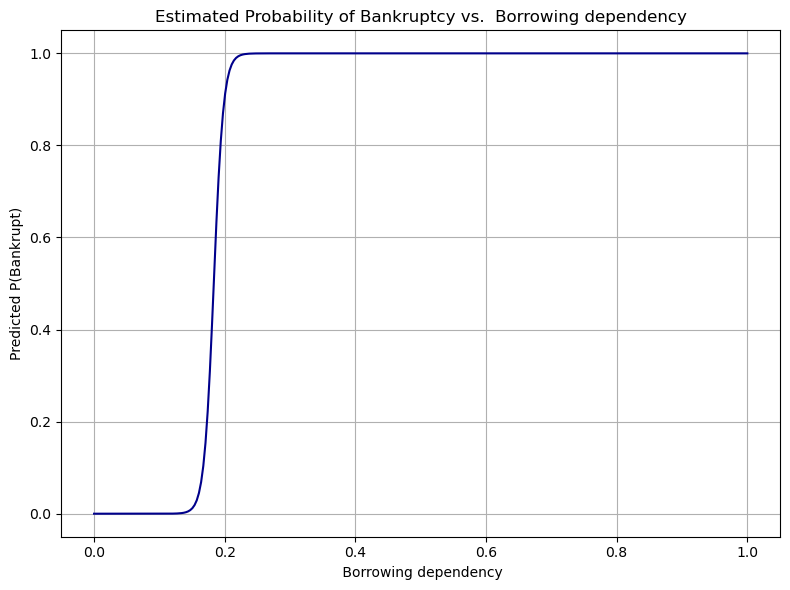

In [14]:
feature_name = ' Borrowing dependency'
feature_index = list(X.columns).index(feature_name)

x_vals = np.linspace(X[feature_name].min(), X[feature_name].max(), 300).reshape(-1, 1)

X_dummy = np.zeros((300, X.shape[1]))
X_dummy[:, feature_index] = x_vals.flatten()

X_dummy_scaled = scaler.transform(X_dummy)

y_proba_dummy = logreg.predict_proba(X_dummy_scaled)[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_proba_dummy, color='darkblue')
plt.xlabel(feature_name)
plt.ylabel('Predicted P(Bankrupt)')
plt.title(f'Estimated Probability of Bankruptcy vs. {feature_name}')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot shows the estimated probability of bankruptcy as a function of Borrowing Dependency, based on the logistic regression model. The relationship is very steep and nonlinear:

When borrowing dependency is below ~0.18, the predicted probability of bankruptcy is close to 0.

As borrowing dependency increases slightly above 0.18, the probability rapidly increases to nearly 1.

This suggests that Borrowing Dependency is a highly influential variable. Even a small increase beyond a certain threshold can sharply increase the risk of bankruptcy.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


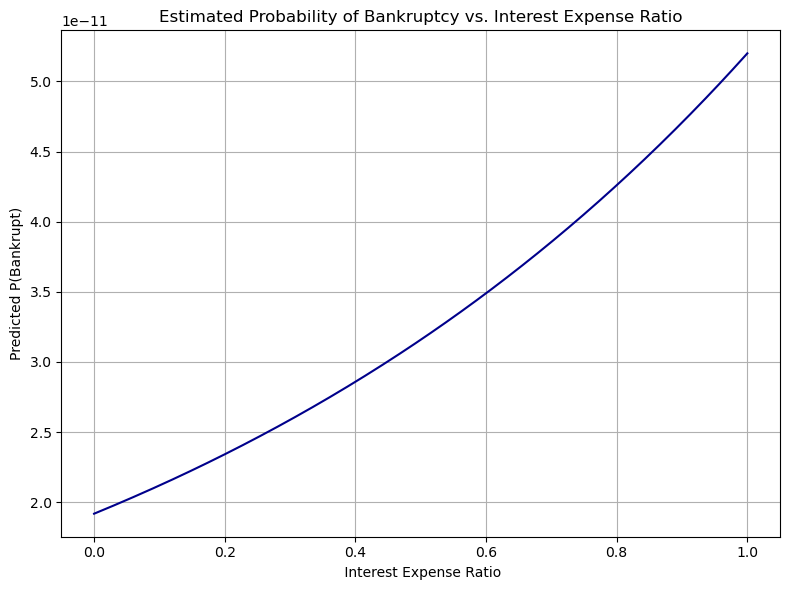

In [15]:
feature_name = ' Interest Expense Ratio'
feature_index = list(X.columns).index(feature_name)

x_vals = np.linspace(X[feature_name].min(), X[feature_name].max(), 300).reshape(-1, 1)

X_dummy = np.zeros((300, X.shape[1]))
X_dummy[:, feature_index] = x_vals.flatten()

X_dummy_scaled = scaler.transform(X_dummy)
y_proba_dummy = logreg.predict_proba(X_dummy_scaled)[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_proba_dummy, color='darkblue')
plt.xlabel(feature_name)
plt.ylabel('Predicted P(Bankrupt)')
plt.title(f'Estimated Probability of Bankruptcy vs.{feature_name}')
plt.grid(True)
plt.tight_layout()
plt.show()


Interest Expense Ratio

The estimated bankruptcy probability increases smoothly and steadily with the interest expense ratio.

This indicates that higher interest burdens on outstanding debt significantly elevate bankruptcy risk.

Companies with poor financing structures or expensive borrowing are more vulnerable.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


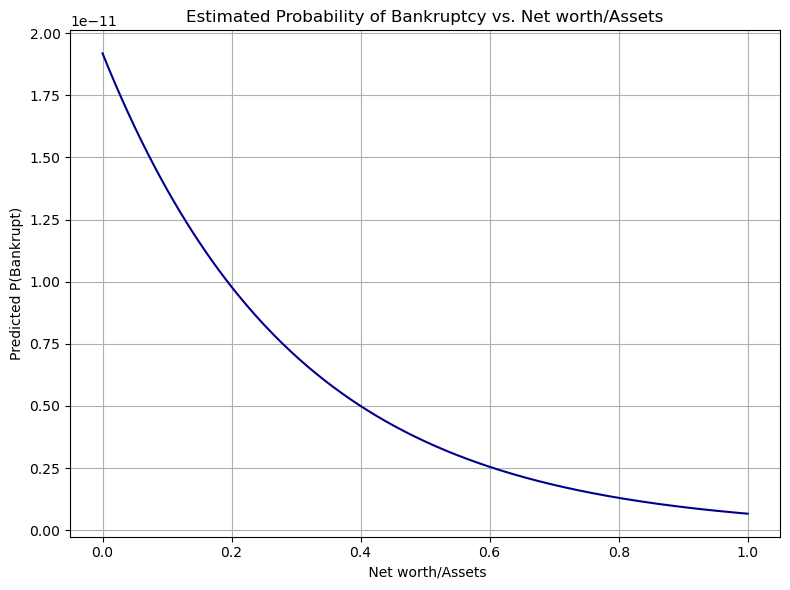

In [16]:
feature_name = ' Net worth/Assets' 
feature_index = list(X.columns).index(feature_name)

x_vals = np.linspace(X[feature_name].min(), X[feature_name].max(), 300).reshape(-1, 1)

X_dummy = np.zeros((300, X.shape[1]))
X_dummy[:, feature_index] = x_vals.flatten()

X_dummy_scaled = scaler.transform(X_dummy)
y_proba_dummy = logreg.predict_proba(X_dummy_scaled)[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_proba_dummy, color='darkblue')
plt.xlabel(feature_name)
plt.ylabel('Predicted P(Bankrupt)')
plt.title(f'Estimated Probability of Bankruptcy vs.{feature_name}')
plt.grid(True)
plt.tight_layout()
plt.show()


Net Worth / Assets

The curve shows a clear inverse relationship: as the net worth relative to total assets increases, the bankruptcy probability decreases exponentially.

Firms with stronger equity positions are more financially stable and thus less likely to go bankrupt.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


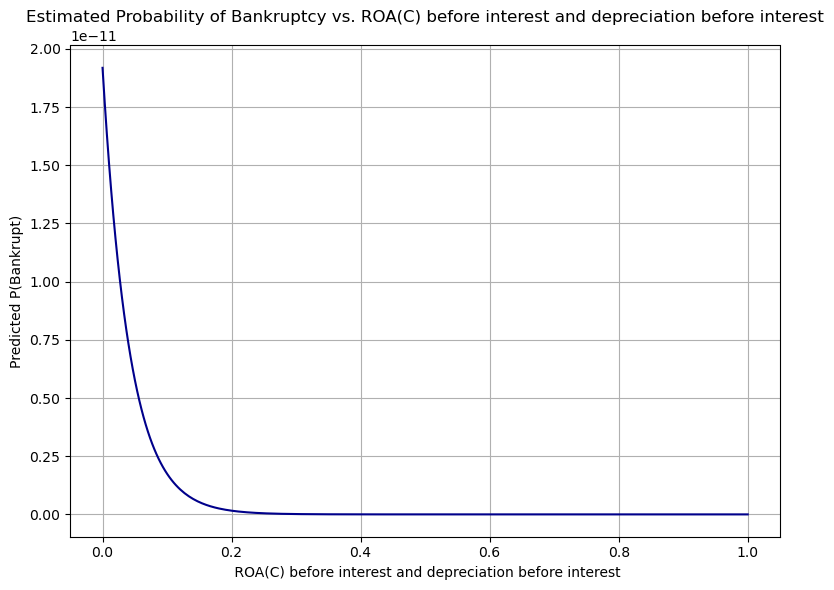

In [17]:
feature_name = ' ROA(C) before interest and depreciation before interest' 
feature_index = list(X.columns).index(feature_name)

x_vals = np.linspace(X[feature_name].min(), X[feature_name].max(), 300).reshape(-1, 1)

X_dummy = np.zeros((300, X.shape[1]))
X_dummy[:, feature_index] = x_vals.flatten()

X_dummy_scaled = scaler.transform(X_dummy)
y_proba_dummy = logreg.predict_proba(X_dummy_scaled)[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_proba_dummy, color='darkblue')
plt.xlabel(feature_name)
plt.ylabel('Predicted P(Bankrupt)')
plt.title(f'Estimated Probability of Bankruptcy vs.{feature_name}')
plt.grid(True)
plt.tight_layout()
plt.show()


ROA(C) before interest and depreciation before interest

The relationship is sharply decreasing: when ROA(C) increases, the probability of bankruptcy drops rapidly.

Even a small improvement in ROA significantly reduces the predicted risk of bankruptcy.

This suggests that profitability (before accounting for costs like interest and depreciation) is a powerful protective factor against financial failure.

In [18]:
dtree = DecisionTreeClassifier(random_state=0)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']
cv_results = cross_validate(dtree, X, y, cv=kfold, scoring=scoring)
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.title():<10}: Mean = {mean:.3f}, Std = {std:.3f}")

Accuracy  : Mean = 0.952, Std = 0.005
Precision : Mean = 0.308, Std = 0.063
Recall    : Mean = 0.373, Std = 0.020
Roc_Auc   : Mean = 0.672, Std = 0.009


Conclusion and Recommendation：

Although the decision tree achieves strong accuracy, its predictive power on the minority class (bankrupt companies) is limited. For tasks where identifying bankrupt firms is critical, improving recall is essential. We recommend:

Tuning model hyperparameters (e.g., max_depth, min_samples_split)

Using class balancing techniques such as class_weight='balanced' or oversampling

Trying ensemble methods like Random Forest or Gradient Boosting for potentially better recall and AUC

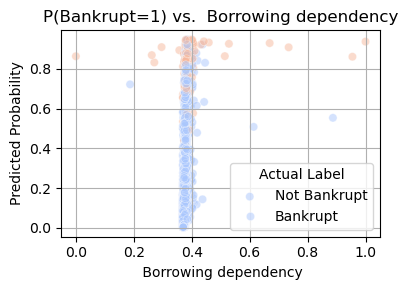

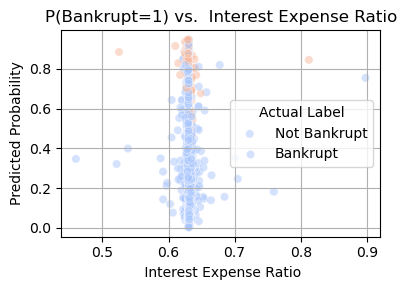

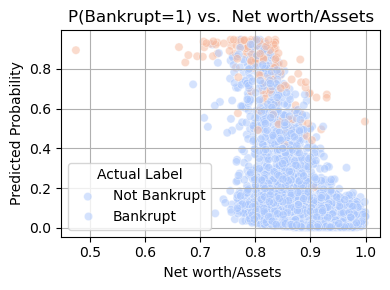

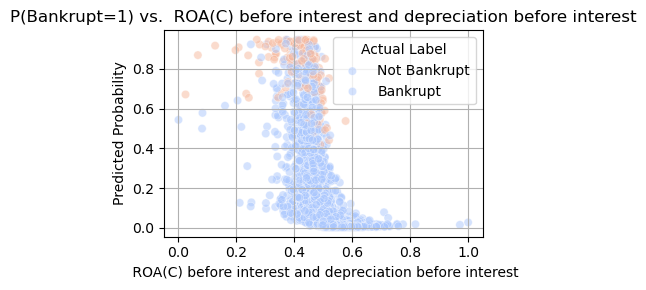

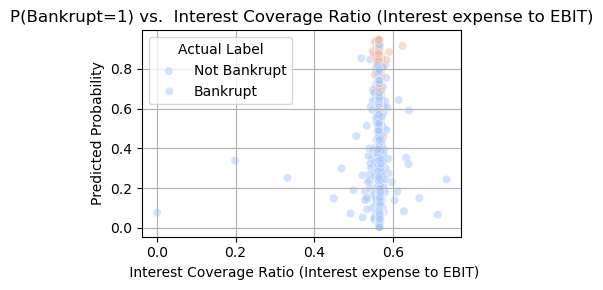

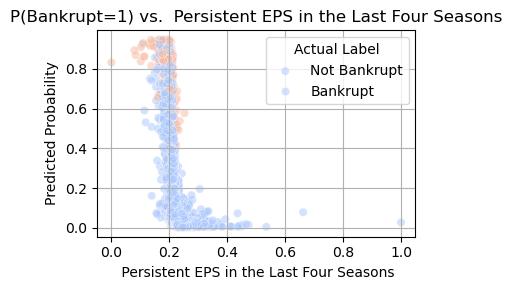

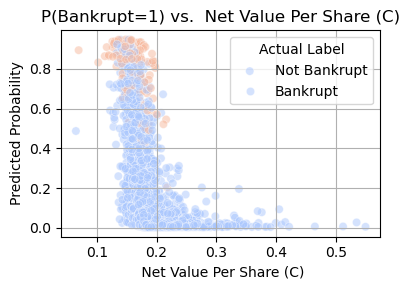

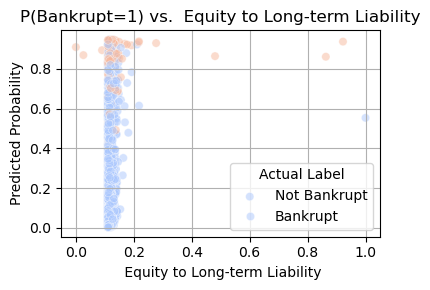

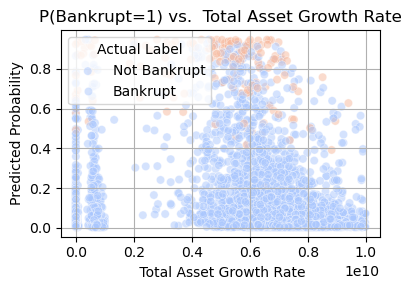

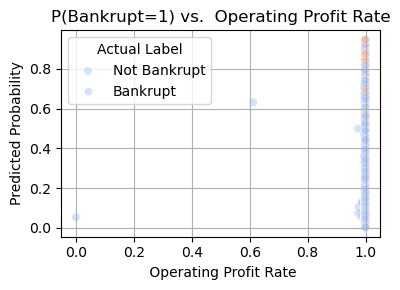

In [20]:
import seaborn as sns
X_train_df = pd.DataFrame(X_train, columns=X.columns)

df_plot = X_train_df.copy()
df_plot['P(Bankrupt=1)'] = best_rf.predict_proba(X_train_scaled)[:, 1]
df_plot['TrueLabel'] = y_train.values

selected_features = [' Borrowing dependency',
    ' Interest Expense Ratio',
    ' Net worth/Assets',
    ' ROA(C) before interest and depreciation before interest',
    ' Interest Coverage Ratio (Interest expense to EBIT)',
    ' Persistent EPS in the Last Four Seasons',
    ' Net Value Per Share (C)',
    ' Equity to Long-term Liability',
    ' Total Asset Growth Rate',
    ' Operating Profit Rate'
  
]


for feature in selected_features:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(x=df_plot[feature], y=df_plot['P(Bankrupt=1)'],
                    hue=df_plot['TrueLabel'], alpha=0.5, palette='coolwarm')
    plt.title(f'P(Bankrupt=1) vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Predicted Probability')
    plt.legend(title='Actual Label', labels=['Not Bankrupt', 'Bankrupt'])
    plt.tight_layout()
    plt.grid(True)
    plt.show()


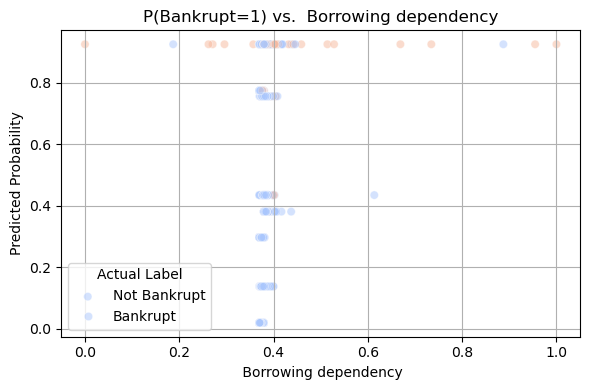

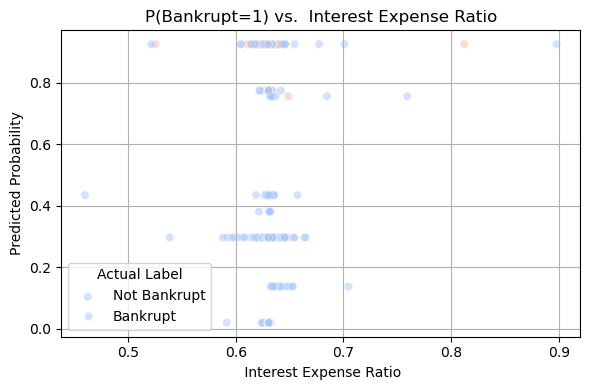

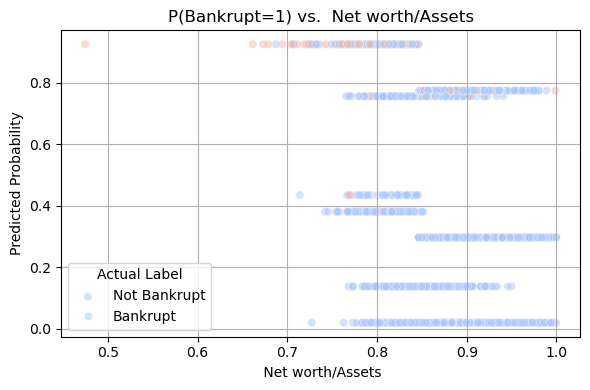

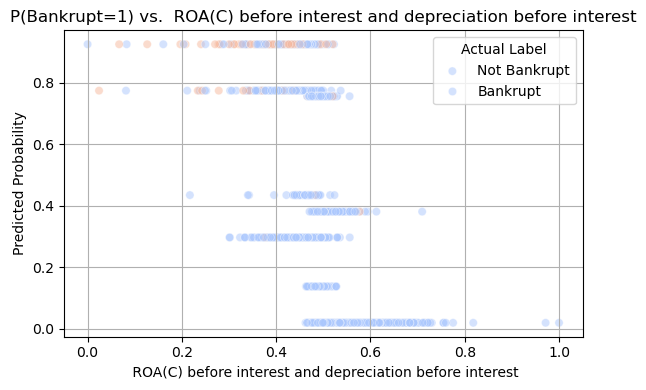

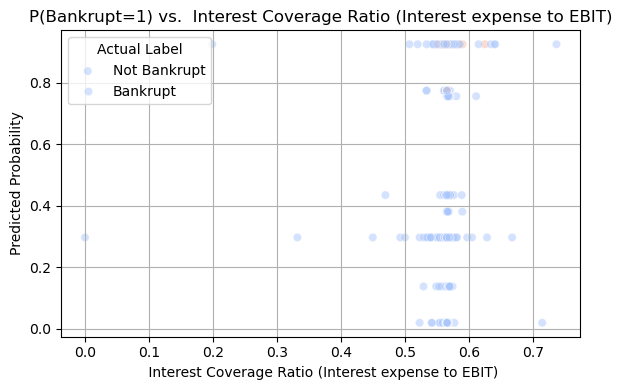

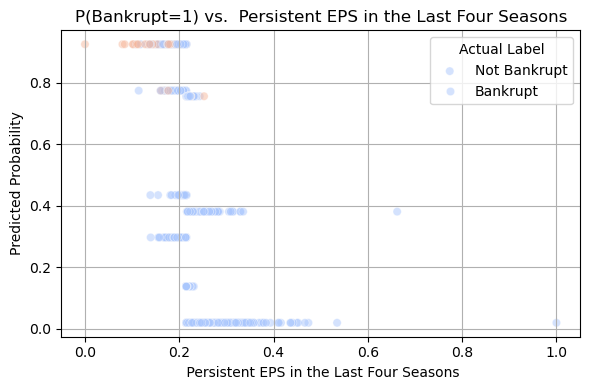

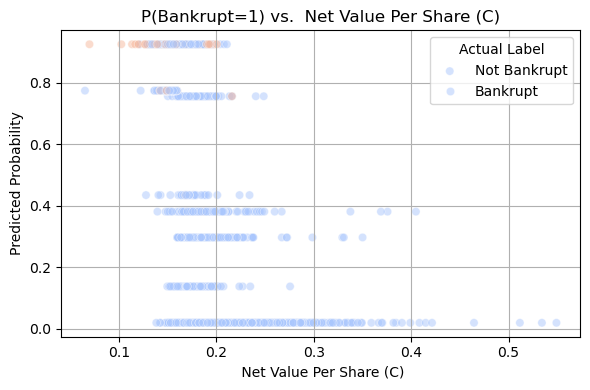

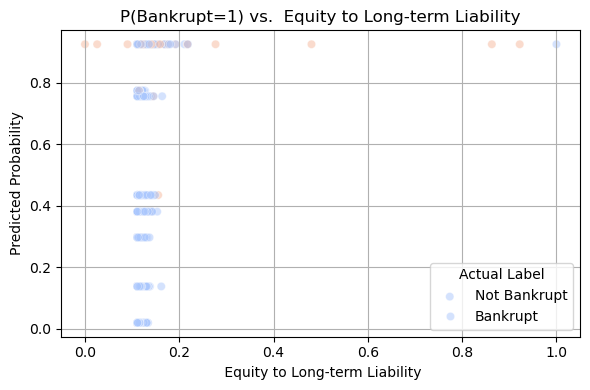

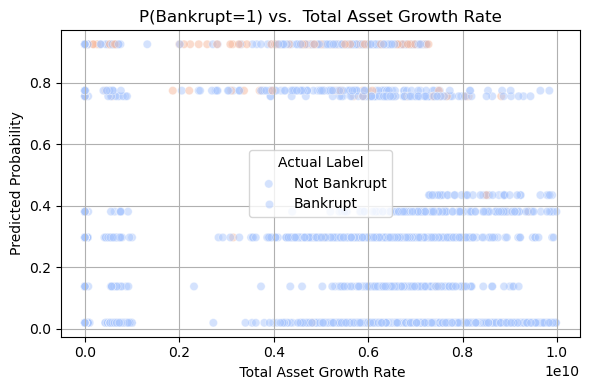

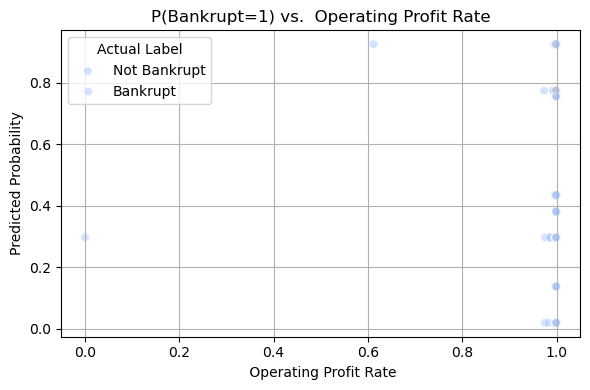

In [21]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)

df_plot = X_train_df.copy()
df_plot['P(Bankrupt=1)'] = best_tree.predict_proba(X_train_scaled)[:, 1]
df_plot['TrueLabel'] = y_train.values

selected_features = [' Borrowing dependency',
    ' Interest Expense Ratio',
    ' Net worth/Assets',
    ' ROA(C) before interest and depreciation before interest',
    ' Interest Coverage Ratio (Interest expense to EBIT)',
    ' Persistent EPS in the Last Four Seasons',
    ' Net Value Per Share (C)',
    ' Equity to Long-term Liability',
    ' Total Asset Growth Rate',
    ' Operating Profit Rate'
  
]


for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df_plot[feature], y=df_plot['P(Bankrupt=1)'],
                    hue=df_plot['TrueLabel'], alpha=0.5, palette='coolwarm')
    plt.title(f'P(Bankrupt=1) vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Predicted Probability')
    plt.legend(title='Actual Label', labels=['Not Bankrupt', 'Bankrupt'])
    plt.tight_layout()
    plt.grid(True)
    plt.show()
